<a href="https://colab.research.google.com/github/SettibathulaJyothi/AI-ML-Internship-Projects/blob/main/Implement_Word_Embeddings_for_IMDB_Dataset_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
pip install numpy tensorflow matplotlib

In [14]:
#Step-by-Step Procedure
#Step 1: Import Required Libraries
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Flatten, Dense
import matplotlib.pyplot as plt

In [16]:
#Step 2: Load and Preprocess IMDB Dataset
# Load IMDB dataset with only the top 10,000 most frequent words
vocab_size = 10000
max_length = 100  # Maximum words per review
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)
# Pad sequences to ensure uniform length
x_train = pad_sequences(x_train, maxlen=max_length, padding='post')
x_test = pad_sequences(x_test, maxlen=max_length, padding='post')

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [17]:
#Step 3: Define the Model with an Embedding Layer
embedding_dim = 16  # Dimension of word embedding vectors
model = Sequential([
Embedding(input_dim=vocab_size, output_dim=embedding_dim,
input_length=max_length),
Flatten(),  # Converts 2D embedding output to 1D
Dense(16, activation='relu'),
Dense(1, activation='sigmoid')  # Binary classification (positive/negative review)
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [18]:
#Step 4: Train the Model
history = model.fit(x_train, y_train, epochs=10, batch_size=32, validation_data=(x_test,
y_test))

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7650 - loss: 0.4568 - val_accuracy: 0.8447 - val_loss: 0.3449
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9178 - loss: 0.2141 - val_accuracy: 0.8381 - val_loss: 0.3787
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9812 - loss: 0.0720 - val_accuracy: 0.8311 - val_loss: 0.4842
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9974 - loss: 0.0153 - val_accuracy: 0.8334 - val_loss: 0.5699
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9990 - loss: 0.0054 - val_accuracy: 0.8246 - val_loss: 0.6691
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9997 - loss: 0.0021 - val_accuracy: 0.8273 - val_loss: 0.7175
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9997 - loss: 0.0019 - val_accuracy: 0.8230 - val_loss: 0.7727
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 1.0000 - loss: 3.7064e-04 - val_accuracy

In [20]:
#Step 5: Visualize Word Embeddings
#After training, we can extract and visualize the word embeddings.
# Extract embeddings from the first layer
embedding_layer = model.layers[0]
weights = embedding_layer.get_weights()[0]
print("Shape of the embedding matrix:", weights.shape)

Shape of the embedding matrix: (10000, 16)


In [21]:
#Step 6: Evaluate the Model
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8277 - loss: 0.8692
Test Accuracy: 0.8277


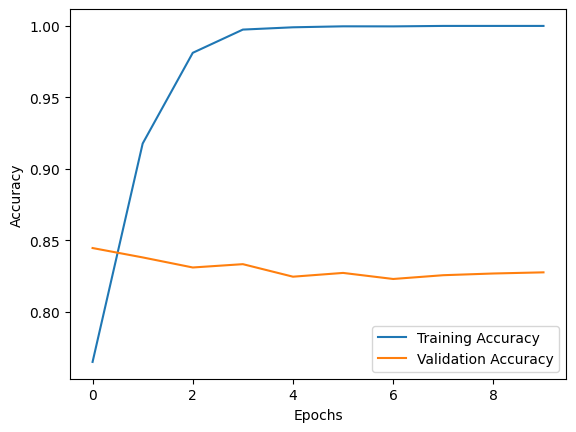

In [22]:
#Step 7: Plot Training History
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()